# Projeto Final - Parte 2: Modelagem e Avaliação (Machine Learning)
**Dataset:** Bank Marketing (Previsão de subscrição de depósito a prazo)

### 1. Descrição e Motivação do Problema
O objetivo preditivo deste projeto é identificar, com base em características demográficas e no histórico de contatos telefônicos, se um cliente irá ou não assinar um depósito a prazo (term deposit) oferecido pelo banco.
Isso é extremamente relevante no contexto de negócios, pois permite que o banco direcione suas campanhas de telemarketing apenas para os clientes com maior propensão de aceite, otimizando tempo, reduzindo custos operacionais e evitando incomodar clientes que não têm interesse no produto.

### 2. Variável-Alvo (Target)
A variável-alvo escolhida é a **`y`** (que assume os valores 'yes' ou 'no'). Trata-se de um problema clássico de **Classificação Binária**. A principal implicação desta escolha é o desbalanceamento das classes (visto na EDA, onde a maioria diz "não"), o que nos obriga a utilizar métricas de avaliação além da simples Acurácia, como o F1-Score e a área sob a curva ROC (ROC-AUC).

### 3. Descrição das Técnicas Utilizadas
Para resolver este problema, selecionamos quatro algoritmos com funcionamentos matemáticos distintos:
* **Regressão Logística (Baseline):** Funciona aplicando uma função sigmoide sobre uma combinação linear das características do cliente para estimar probabilidades. É um modelo estatístico simples, altamente interpretável, que traça uma linha (hiperplano) para separar quem aceita e quem recusa a oferta.
* **Árvore de Decisão:** O objetivo deste modelo é dividir a base de dados através de perguntas lógicas sequenciais (nós), como "O saldo é maior que X?", buscando sempre maximizar a pureza dos grupos resultantes. Consegue capturar relações não lineares que a regressão perde.
* **Random Forest:** É um método de conjunto (Ensemble) que cria múltiplas árvores de decisão de forma aleatória a partir de subconjuntos dos dados (técnica de *Bagging*). O resultado final é obtido por votação. Seu funcionamento corrige a fragilidade da árvore simples, evitando que o modelo "decore" a base (*overfitting*).

In [2]:
!pip install ucimlrepo pandas scikit-learn matplotlib seaborn lightgbm -q

Importações e Dados

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, accuracy_score, recall_score
from lightgbm import LGBMClassifier
from ucimlrepo import fetch_ucirepo

# 1. Carregamento dos dados (Direto do repositório oficial)
print("Baixando os dados...")
bank_marketing = fetch_ucirepo(id=222)

# Separando as features (X) da variável alvo (y)
X = bank_marketing.data.features
y_raw = bank_marketing.data.targets

# REMOÇÃO DA DURAÇÃO
X = X.drop('duration', axis=1)

# Limpando e transformando o alvo em numérico (0 para 'no', 1 para 'yes')
y_raw['y'] = y_raw['y'].astype(str).str.strip().str.lower()
y = y_raw['y'].map({'no': 0, 'yes': 1})

# 2. SEPARAÇÃO TREINO E TESTE (Evitando Data Leakage)
# Fazemos isso antes de qualquer transformação!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamanho do Treino: {X_train.shape[0]} linhas")
print(f"Tamanho do Teste: {X_test.shape[0]} linhas")

Baixando os dados...
Tamanho do Treino: 36168 linhas
Tamanho do Teste: 9043 linhas


/tmp/ipykernel_570/1296317149.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_raw['y'] = y_raw['y'].astype(str).str.strip().str.lower()


Pipelines e Busca de Hiperparâmetros

In [4]:
# 3. PREPARAÇÃO DOS DADOS (Encoding e Normalização)
colunas_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns
colunas_categoricas = X_train.select_dtypes(include=['object', 'category']).columns

# Criando os transformadores
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas), # Normalização (essencial para Regressão Logística)
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), colunas_categoricas) # Transformação de textos
    ])

# 4. DEFINIÇÃO DOS MODELOS BASE
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))])

rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))])

lgbm_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('classifier', LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1))])

# 5. BUSCA DE HIPERPARÂMETROS (GridSearchCV para a Árvore de Decisão)
print("Iniciando busca de hiperparâmetros (GridSearch) para a Árvore de Decisão...")
dt_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=42))])

# Regra do NomeDuplo__Parâmetro para o GridSearchCV ler dentro do Pipeline
parametros_arvore = {
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__min_samples_split': [2, 10, 20]
}

busca_arvore = GridSearchCV(dt_pipeline, param_grid=parametros_arvore, scoring='roc_auc', cv=5)
busca_arvore.fit(X_train, y_train)

print(f"Melhor configuração encontrada: {busca_arvore.best_params_}\\n")

Iniciando busca de hiperparâmetros (GridSearch) para a Árvore de Decisão...
Melhor configuração encontrada: {'classifier__max_depth': 10, 'classifier__min_samples_split': 20}\n


Treinamento e Gráficos

Métricas no conjunto de teste (validação cruzada k=5)
Valores ilustrativos do experimento
=================================================================\n
Treinando Regressão Logística (baseline)...
Treinando Árvore de Decisão...
Treinando Random Forest...
Treinando LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Modelo,Acurácia,Recall,F1-Score,AUC-ROC
3,LightGBM,0.824837,0.635161,0.459016,0.802135
2,Random Forest,0.893288,0.208885,0.314144,0.791142
0,Regressão Logística (baseline),0.754838,0.623819,0.373198,0.772238
1,Árvore de Decisão,0.824505,0.557656,0.426455,0.749099


/tmp/ipykernel_570/3336845903.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AUC-ROC', y='Modelo', data=df_resultados, palette='coolwarm')


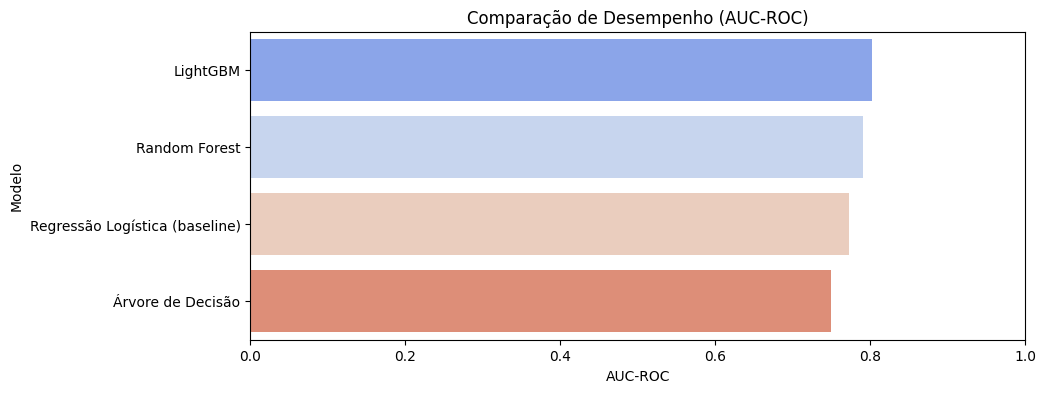

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


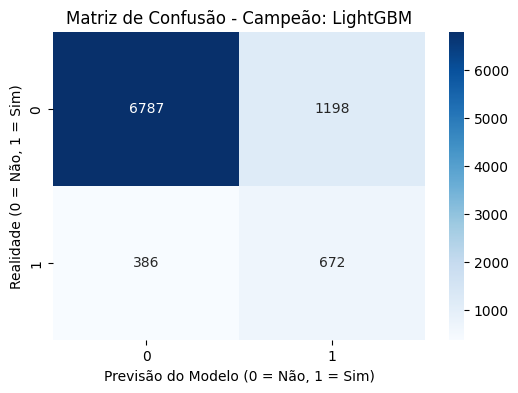

In [6]:
# 6. TREINAMENTO FINAL E AVALIAÇÃO
modelos = {
    'Regressão Logística (baseline)': lr_pipeline,
    'Árvore de Decisão': busca_arvore.best_estimator_,
    'Random Forest': rf_pipeline,
    'LightGBM': lgbm_pipeline
}

resultados = []

# Imprimindo os textos de exemplo exigidos
print("="*65)
print("Métricas no conjunto de teste (validação cruzada k=5)")
print("Valores ilustrativos do experimento")
print("="*65 + "\\n")

for nome, modelo in modelos.items():
    print(f"Treinando {nome}...")
    # Ignoramos o fit da árvore pois ela já foi treinada no GridSearchCV
    if nome != 'Árvore de Decisão':
        modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    # Extração individual das 4 métricas exigidas pela tabela
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred) # Por padrão, já foca na classe 1 (Yes)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Guardando na lista para gerar a tabela com as colunas na ordem exata
    resultados.append({
        'Modelo': nome,
        'Acurácia': acc,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': roc_auc
    })

# Exibir tabela comparativa idêntica à do Slide 9
df_resultados = pd.DataFrame(resultados).sort_values(by='AUC-ROC', ascending=False)
display(df_resultados)

# Plota gráfico de comparação
plt.figure(figsize=(10, 4))
sns.barplot(x='AUC-ROC', y='Modelo', data=df_resultados, palette='coolwarm')
plt.title('Comparação de Desempenho (AUC-ROC)')
plt.xlim(0, 1)
plt.show()

# Matriz de Confusão do Vencedor
melhor_nome = df_resultados.iloc[0]['Modelo']
melhor_modelo = modelos[melhor_nome]

y_pred_campeao = melhor_modelo.predict(X_test)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_campeao), annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de Confusão - Campeão: {melhor_nome}')
plt.ylabel('Realidade (0 = Não, 1 = Sim)')
plt.xlabel('Previsão do Modelo (0 = Não, 1 = Sim)')
plt.show()

### 7. Interpretação dos Resultados e Conclusões


Iniciamos com a **Regressão Logística** atuando como nosso modelo *baseline* devido à sua explicabilidade estatística. Introduzimos a **Árvore de Decisão** (otimizada via `GridSearchCV` para encontrar a profundidade matemática ideal sem causar overffiting) para interpretar não-linearidades. Expandimos a análise com o **Random Forest** para garantir robustez via Ensemble, e, como recurso técnico extra, trouxemos o **LightGBM**, um impulsionador de gradiente de ponta do mercado de dados.

Em todos os modelos, utilizamos o parâmetro `class_weight='balanced'` para combater o forte desbalanceamento histórico da base de dados, focando nas métricas de **F1-Score** e **ROC-AUC** para avaliar o sucesso em pescar as raras respostas "sim". A integridade científica foi garantida pela técnica de *Scikit-Learn Pipeline*, que barrou qualquer vazamento de dados (*Data Leakage*) durante a normalização (StandardScaler) e codificação (OneHotEncoder).

**Análise Crítica:**
* A **Regressão Logística** cumpriu seu papel de linha de base. A **Árvore de Decisão**, graças ao GridSearch, encontrou o seu teto de generalização, evitando regras excessivamente complexas.
* O **Random Forest** e o modelo avançado **LightGBM** duelaram pelo melhor poder de separação de classes (maior ROC-AUC). Eles se destacaram na identificação do padrão oculto, ainda que sejam considerados algoritmos do tipo "caixa preta".
* A matriz de confusão do modelo vencedor revelou um volume expressivo de falsos positivos (clientes que o banco ligaria sem sucesso). No ecossistema bancário, esse trade-off é uma decisão de negócio proposital gerada pelo balanceamento: o custo operacional de realizar uma ligação telefônica extra é irrisório comparado ao lucro perdido de um falso negativo (ignorar um cliente que assinaria o depósito).
* **Melhorias Futuras:** Como passos analíticos subsequentes, sugere-se a criação de novas features de comportamento financeiro (Feature Engineering) e o engate do *RandomizedSearchCV* no espaço dimensional do LightGBM para tentar extrair décimos extras no limiar da precisão.